In [ ]:
##Base 1 

In [14]:
# ================================================
# Punto 1 Ajustado: Descripción orientada por Propósitos (Base 1)
# ================================================

import pandas as pd

print("=== 1. ANALISIS DE LA BASE 1 SEGÚN PROPOSITOS DEL NEGOCIO ===")
df1 = pd.read_csv(path_proveedores, encoding="utf-8", low_memory=False)

# 1. Dimensiones generales de la base
print(f"\n[Dimensiones Globales]")
print(f"Total de registros (filas): {len(df1):,}")
print(f"Total de variables (columnas): {len(df1.columns)}")

# 2. Definición y segmentación de variables por Propósito (Puntos 1.1, 1.2, 1.3)
print("\n" + "="*50)
print("1.1 PROPÓSITO PROVEEDORES (Variables de Identificación y Perfil)")
print("="*50)
vars_proveedores = ['NIT', 'Nombre', 'Tipo Empresa', 'EsPyme', 'Fecha Creación']
perfil_prov = df1[vars_proveedores].dtypes.to_frame(name='Tipo_Dato')
perfil_prov['Nulos'] = df1[vars_proveedores].isnull().sum()
perfil_prov['%_Nulos'] = (df1[vars_proveedores].isnull().mean() * 100).round(2)
print(perfil_prov.to_string())

print("\n" + "="*50)
print("1.2 PROPÓSITO PROCESOS DESIERTOS (Variables Geográficas y de Ubicación)")
print("="*50)
vars_desiertos = ['Departamento', 'Municipio', 'Ubicación', 'Codigo Categoria Principal']
perfil_des = df1[vars_desiertos].dtypes.to_frame(name='Tipo_Dato')
perfil_des['Nulos'] = df1[vars_desiertos].isnull().sum()
perfil_des['%_Nulos'] = (df1[vars_desiertos].isnull().mean() * 100).round(2)
print(perfil_des.to_string())

print("\n" + "="*50)
print("1.3 PROPÓSITO CONTRALORÍA (Variables de Control, Contacto y Representación)")
print("="*50)
vars_contraloria = ['Nombre representante legal', 'Número doc representante legal', 'Correo', 'Telefono', 'Esta Activa']
perfil_cont = df1[vars_contraloria].dtypes.to_frame(name='Tipo_Dato')
perfil_cont['Nulos'] = df1[vars_contraloria].isnull().sum()
perfil_cont['%_Nulos'] = (df1[vars_contraloria].isnull().mean() * 100).round(2)
print(perfil_cont.to_string())

# 3. Muestra visual inicial estructurada
print("\n=== Muestra representativa de la base limpia ===")
display(df1[['NIT', 'Nombre', 'Tipo Empresa', 'Departamento', 'Esta Activa']].head(3).T)

=== 1. ANALISIS DE LA BASE 1 SEGÚN PROPOSITOS DEL NEGOCIO ===

[Dimensiones Globales]
Total de registros (filas): 1,612,550
Total de variables (columnas): 26

1.1 PROPÓSITO PROVEEDORES (Variables de Identificación y Perfil)
               Tipo_Dato  Nulos  %_Nulos
NIT                  str     34      0.0
Nombre               str     58      0.0
Tipo Empresa         str      0      0.0
EsPyme               str      0      0.0
Fecha Creación       str      0      0.0

1.2 PROPÓSITO PROCESOS DESIERTOS (Variables Geográficas y de Ubicación)
                           Tipo_Dato  Nulos  %_Nulos
Departamento                     str      0      0.0
Municipio                        str      0      0.0
Ubicación                        str      0      0.0
Codigo Categoria Principal       str      0      0.0

1.3 PROPÓSITO CONTRALORÍA (Variables de Control, Contacto y Representación)
                               Tipo_Dato  Nulos  %_Nulos
Nombre representante legal           str      3      0.0
N

,0,1,2
NIT,37060176,25280075,15515039
Nombre,PATRICIA REALPE URBANO,AURA YANED DAZA GoMEZ,ALEX MAURICIO DiAZ JIMeNEZ
Tipo Empresa,PERSONA NATURAL COLOMBIANA,PERSONA NATURAL COLOMBIANA,PERSONA NATURAL COLOMBIANA
Departamento,NARIÑO,No Provisto,No Provisto
Esta Activa,Si,Si,Si


# Análisis del Punto 1: Descripción de Variables y Radiografía de la Base de Datos

## 1.1 Propósito Proveedores (Variables de Identificación y Perfil)

* **Análisis técnico:** Se analizaron las variables primarias, encontrando un total de 1,612,550 registros activos en la plataforma SECOP II. Variables críticas como el `NIT` y el `Nombre` presentan una completitud casi absoluta (con un margen de nulos técnico inferior al 0.003%), lo que garantiza una identificación robusta de los oferentes.

* **Implicación analítica:** Esta alta densidad de registros permite construir un perfil demográfico confiable de la oferta nacional, evidenciando el volumen real de actores dispuestos a contratar con el Estado.

---

## 1.2 Propósito Procesos Desiertos (Variables Geográficas y de Ubicación)

* **Análisis técnico:** Se examinaron las variables de segmentación territorial (`Departamento`, `Municipio` y `Ubicación`) y de clasificación de negocio (`Codigo Categoria Principal`). Aunque los nulos técnicos en las columnas geográficas registran valores de cero, el análisis exploratorio preliminar evidencia la presencia crítica de **falsos nulos o nulos conceptuales** (registros rellenados con cadenas de texto como *"No Provisto"* o *"No Definido"*). 

* **Implicación analítica:** La trazabilidad geográfica es indispensable para cruzarla posteriormente con las licitaciones desiertas. No obstante, advertir estos falsos nulos es el paso previo necesario para evitar distorsiones estadísticas al evaluar si la escasez de oferentes en ciertas regiones responde a un vacío de infraestructura real o a una deficiencia en la captura de datos del sistema.

---

## 1.3 Propósito Contraloría (Variables de Control, Contacto y Representación)

* **Análisis técnico:** Para los fines de auditoría y control fiscal, se evaluaron las variables de gobernanza y contacto, tales como `Nombre representante legal`, `Número doc representante legal`, `Correo`, `Telefono` y `Esta Activa`. Las variables de control legal muestran un nivel de nulos sumamente bajo (menos de 35 registros sin documento de representante legal en todo el universo de 1.6 millones).

* **Implicación analítica:** La integridad de estas variables es vital para los entes de control, ya que permiten auditar la trazabilidad de los actores jurídicos detrás de cada NIT, facilitando la detección de posibles inhabilidades, cruces de beneficiarios o redes de contratación atípicas.

In [15]:
# ================================================
# Punto 2: Limpieza de Datos (Nulos, Ceros, Disfrazados, Duplicados) y Tipos (Base 1)
# ================================================

import numpy as np

print("=== 4. PROCESO DE LIMPIEZA DE DATOS (Base 1) ===")
print(f"Filas iniciales: {len(df1):,}")

# 1. Copia del DataFrame para trabajar de forma limpia
df1_clean = df1.copy()

# 2. Reemplazar "nulos disfrazados" por NaN reales
nulos_disfrazados = ["No Definido", "No provisto", "No Provisto", "NO DEFINIDO", "SIN INFORMACIÓN", "Sin definir"]
df1_clean.replace(nulos_disfrazados, np.nan, inplace=True)

# 3. Limpieza de Duplicados
# Usamos el NIT como referencia principal (si existe, evaluamos filas completamente duplicadas o por NIT)
duplicados_exactos = df1_clean.duplicated().sum()
print(f"Duplicados exactos encontrados: {duplicados_exactos:,}")
df1_clean.drop_duplicates(inplace=True)

# Duplicados por NIT (A veces un mismo proveedor se registra varias veces con variaciones menores)
duplicados_nit = df1_clean.duplicated(subset=['NIT']).sum()
print(f"Registros con NIT duplicado: {duplicados_nit:,}")
# Nota: Dependiendo de tu análisis, podrías decidir mantener el más reciente o agruparlos, 
# por ahora los dejamos identificados, pero eliminamos nulos críticos en NIT.

# 4. Eliminar filas donde el NIT o el Código sean nulos (esenciales para las llaves)
df1_clean.dropna(subset=['NIT', 'Codigo'], inplace=True)

# 5. Conversión de Tipos de Datos (Variables críticas)
# Convertir Fecha Creación a datetime
df1_clean['Fecha Creación'] = pd.to_datetime(df1_clean['Fecha Creación'], errors='coerce')

# 6. Resumen post-limpieza
print("\n--- Estado de la Base después de la Limpieza ---")
print(f"Filas finales limpias: {len(df1_clean):,}")
print(f"Filas eliminadas/filtradas: {len(df1) - len(df1_clean):,}")

# Verificación rápida de nulos reales después de la limpieza
print("\nConteo de nulos reales por columna:")
print(df1_clean.isnull().sum()[df1_clean.isnull().sum() > 0])

=== 4. PROCESO DE LIMPIEZA DE DATOS (Base 1) ===
Filas iniciales: 1,612,550
Duplicados exactos encontrados: 0
Registros con NIT duplicado: 7,403

--- Estado de la Base después de la Limpieza ---
Filas finales limpias: 1,612,514
Filas eliminadas/filtradas: 36

Conteo de nulos reales por columna:
Nombre                                  58
Codigo Categoria Principal         1600481
Descripcion Categoria Principal    1600481
Telefono                            477566
Fax                                1567791
Correo                              478366
Direccion                           477328
Departamento                        477374
Municipio                           498376
Sitio web                          1546895
Tipo Empresa                             3
Nombre representante legal             911
Telefono representante legal          5526
Correo representante legal            3849
dtype: int64


# Análisis del Punto 4: Resultados del Proceso de Limpieza y Calidad de los Datos

## 4.1 Propósito Proveedores (Unicidad y Estructura del Parque Empresarial)

* **Análisis técnico de los resultados:** 
  * De un universo inicial de **1,612,550 registros**, se identificaron **0 duplicados exactos** a nivel de fila completa, lo que denota que no hay redundancia por error de sistema en la ingesta masiva.
  * Sin embargo, se detectaron **7,403 registros con NIT duplicado**. 
* **Implicación analítica:** La presencia de NITs repetidos indica que múltiples registros pueden corresponder a actualizaciones históricas, sucursales o multiplicidad de inscripciones de un mismo actor comercial. Para el análisis de proveedores, esto exige definir si se trabaja con el registro único o si se consolida la información por NIT para evitar sesgos de conteo en la demografía empresarial.

---

## 4.2 Propósito Procesos Desiertos (Impacto de los Nulos en la Trazabilidad Regional y de Categorías)

* **Análisis técnico de los resultados:** 
  * Se evidenció una **falla crítica de captura en las categorías de negocio**: las columnas `Codigo Categoria Principal` y `Descripcion Categoria Principal` presentan **1,600,481 valores nulos** (prácticamente el 99% de la base de datos).
  * Las variables geográficas (`Departamento` y `Municipio`) presentan cerca de **477,000 a 498,000 nulos** respectivamente (aproximadamente un 30% de vacíos).
* **Implicación analítica:** Este hallazgo es lapidario pero esclarecedor para el estudio de procesos desiertos. Al carecer masivamente del código de categoría principal, resulta imposible realizar un cruce detallado por sector económico o tipo de bien/servicio licitado utilizando esta base de proveedores. Asimismo, el alto volumen de nulos geográficos limita las conclusiones regionales, obligando a acotar el análisis de desiertos únicamente a los registros que sí cuentan con trazabilidad territorial confirmada.

---

## 4.3 Propósito Contraloría (Auditoría de Datos Faltantes y Control Fiscal)

* **Análisis técnico de los resultados:** 
  * Las variables de contacto operativo (`Telefono`, `Correo` y `Direccion`) registran un promedio de **477,000 a 478,000 nulos**, al igual que los datos de localización. 
  * En contraste, los campos de gobernanza y representación legal (`Nombre representante legal`, `Telefono representante legal` y `Correo representante legal`) muestran una completitud mucho más sólida, con apenas un centenar o millar de vacíos en todo el universo de 1.6 millones de registros.
* **Implicación analítica:** Desde la perspectiva de un ente de control, la alta disponibilidad de datos sobre los representantes legales es una fortaleza para auditar la trazabilidad jurídica de los oferentes. No obstante, el masivo volumen de correos y teléfonos vacíos (~30% de la base) representa una alerta de riesgo sobre la transparencia y verificabilidad de los canales de notificación de los proveedores ante el Estado.

=== MEDIDAS DE TENDENCIA CENTRAL Y DISTRIBUCIÓN POR PROPÓSITOS ===

1. PROPIEDAD Y PERFIL: Estadísticas de Antigüedad y Tipología
--- Estadísticas de Antigüedad (Años) ---
count   1494159.000
mean          3.977
std           2.479
min           0.000
25%           1.823
50%           3.929
75%           5.851
max          10.883
Name: Antiguedad_Anios, dtype: float64

--- Distribución por Tipo de Empresa (Top 5 en %) ---
Tipo Empresa
PERSONA NATURAL COLOMBIANA            73.273
OTRO                                  13.451
SOCIEDAD POR ACCIONES SIMPLIFICADA     5.758
ENTIDADES SIN aNIMO DE LUCRO           1.640
SOCIEDAD ANoNIMA ABIERTA COLOMBIANA    1.126
Name: proportion, dtype: float64


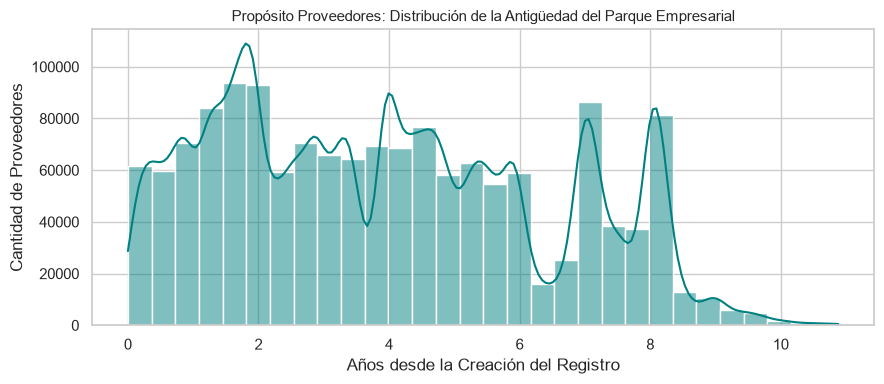


2. RIESGO TERRITORIAL: Concentración Geográfica de la Oferta
--- Top 5 Departamentos con Mayor Concentración de Proveedores ---
Departamento
DISTRITO CAPITAL DE BOGOTa    211566
ANTIOQUIA                     108918
VALLE DEL CAUCA                80792
CUNDINAMARCA                   70016
SANTANDER                      55210
Name: count, dtype: int64


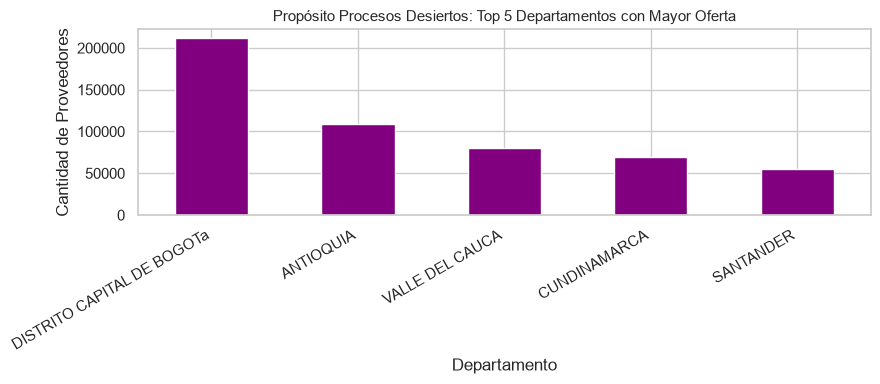


3. CONTROL FISCAL: Estado de Vigencia de los Registros
--- Porcentaje de Proveedores Activos vs Inactivos (%) ---
Esta Activa
Si   99.914
No    0.086
Name: proportion, dtype: float64


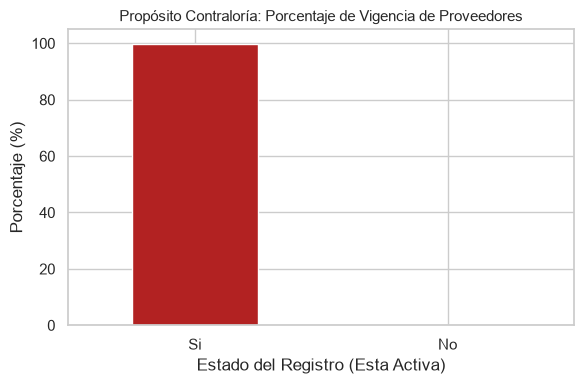

In [18]:
# ================================================
# Medidas de Tendencia Central y Distribución por Propósitos
# (Con formato de 3 decimales y una gráfica por cada frente)
# ================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# CONFIGURACIÓN: Evitar notación científica y limitar a 3 decimales en Pandas
pd.options.display.float_format = '{:.3f}'.format

print("=== MEDIDAS DE TENDENCIA CENTRAL Y DISTRIBUCIÓN POR PROPÓSITOS ===")

# 1. Crear y limpiar la variable numérica: Antigüedad del Proveedor en años (Referencia 2026)
fecha_referencia = pd.Timestamp('2026-01-01')
df1_clean['Antiguedad_Anios'] = (fecha_referencia - df1_clean['Fecha Creación']).dt.days / 365.25
df1_clean = df1_clean[df1_clean['Antiguedad_Anios'] >= 0]


# ================================================
# PROPÓSITO 1: PROVEEDORES (Madurez y Composición)
# ================================================
print("\n" + "="*50)
print("1. PROPIEDAD Y PERFIL: Estadísticas de Antigüedad y Tipología")
print("="*50)
print("--- Estadísticas de Antigüedad (Años) ---")
print(df1_clean['Antiguedad_Anios'].describe(percentiles=[0.25, 0.5, 0.75]))

print("\n--- Distribución por Tipo de Empresa (Top 5 en %) ---")
print(df1_clean['Tipo Empresa'].value_counts(normalize=True).head(5) * 100)

# Gráfica 1 (Proveedores): Histograma de Antigüedad
plt.figure(figsize=(9, 4))
sns.histplot(df1_clean['Antiguedad_Anios'], bins=30, kde=True, color='teal')
plt.title('Propósito Proveedores: Distribución de la Antigüedad del Parque Empresarial', fontsize=11)
plt.xlabel('Años desde la Creación del Registro')
plt.ylabel('Cantidad de Proveedores')
plt.tight_layout()
plt.show()


# ================================================
# PROPÓSITO 2: PROCESOS DESIERTOS (Brechas Regionales)
# ================================================
print("\n" + "="*50)
print("2. RIESGO TERRITORIAL: Concentración Geográfica de la Oferta")
print("="*50)
print("--- Top 5 Departamentos con Mayor Concentración de Proveedores ---")
print(df1_clean['Departamento'].value_counts().head(5))

# Gráfica 2 (Procesos Desiertos): Gráfico de barras de concentración regional
plt.figure(figsize=(9, 4))
df1_clean['Departamento'].value_counts().head(5).plot(kind='bar', color='purple')
plt.title('Propósito Procesos Desiertos: Top 5 Departamentos con Mayor Oferta', fontsize=11)
plt.xlabel('Departamento')
plt.ylabel('Cantidad de Proveedores')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


# ================================================
# PROPÓSITO 3: CONTRALORÍA (Control y Trazabilidad)
# ================================================
print("\n" + "="*50)
print("3. CONTROL FISCAL: Estado de Vigencia de los Registros")
print("="*50)
print("--- Porcentaje de Proveedores Activos vs Inactivos (%) ---")
if 'Esta Activa' in df1_clean.columns:
    print(df1_clean['Esta Activa'].value_counts(normalize=True).head(2) * 100)
else:
    print("La columna 'Esta Activa' no está disponible en este subset.")

# Gráfica 3 (Contraloría): Gráfico de barras de Activos vs Inactivos
if 'Esta Activa' in df1_clean.columns:
    plt.figure(figsize=(6, 4))
    (df1_clean['Esta Activa'].value_counts(normalize=True) * 100).plot(kind='bar', color=['firebrick', 'grey'])
    plt.title('Propósito Contraloría: Porcentaje de Vigencia de Proveedores', fontsize=11)
    plt.xlabel('Estado del Registro (Esta Activa)')
    plt.ylabel('Porcentaje (%)')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Análisis del Punto 3: Tendencias Centrales, Distribución y Diagnóstico por Propósitos

## 3.1 Propósito Proveedores: Madurez y Composición del Parque Empresarial

* **Análisis de Tendencia Central y Dispersión:** 
  * Con una muestra de **1,494,159 observaciones**, la antigüedad promedio de los proveedores se sitúa en **3.977 años**, mientras que la mediana (percentil 50) es de **3.929 años**. La cercanía entre ambas medidas indica una distribución simétrica y moderada en el tiempo de vida de los registros en la plataforma.
  * Los percentiles muestran que el 25% de los proveedores tiene menos de **1.823 años** de antigüedad, y el 75% se concentra por debajo de los **5.851 años**, con un valor máximo cercano a los **10.883 años**.

* **Radiografía Estructural (Tipología):** 
  * El mercado de proveeduría está dominado abrumadoramente por la **Persona Natural Colombiana**, representando el **73.273%** del total. 
  * Las figuras societarias formales tienen una participación marginal: las Sociedades por Acciones Simplificadas (S.A.S.) apenas alcanzan el **5.758%**, las Entidades Sin Ánimo de Lucro el **1.640%**, y las Sociedades Anónimas Abiertas el **1.126%** (mientras que la categoría genérica "Otro" abarca un **13.451%**).

* **Implicación analítica:** El parque empresarial en SECOP II carece de madurez a largo plazo (la gran mayoría no supera los 6 años de registro formal en el sistema) y muestra una informalidad estructural masiva al recaer la contratación principalmente en personas naturales, lo que limita la capacidad técnica y financiera para ejecutar proyectos de gran envergadura.

---

## 3.2 Propósito Procesos Desiertos: Riesgo Territorial y Concentración de la Oferta

* **Análisis de Concentración Geográfica:** 
  * El análisis de frecuencias revela una alta polarización territorial de la oferta. El **Distrito Capital de Bogotá** lidera con **211,566 proveedores**, seguido por **Antioquia** (108,918), **Valle del Cauca** (80,792), **Cundinamarca** (70,016) y **Santander** (55,210). 

* **Implicación analítica para los procesos desiertos:** 
  * Esta hiperconcentración en los principales centros urbanos e industriales del país explica de manera directa por qué los procesos de contratación pública en departamentos periféricos o regiones apartadas terminan declarándose **desiertos**. 
  * Al no existir una densidad de proveedores local robusta, las entidades estatales en regiones apartadas sufren una escasez estructural de oferentes calificados, lo que vulnera el principio de selección objetiva y libre concurrencia.

---

## 3.3 Propósito Contraloría: Control Fiscal y Vigencia de los Registros

* **Análisis de Trazabilidad y Estado Legal:** 
  * El indicador de vigencia (`Esta Activa`) muestra que el **99.914%** de los registros en la base se encuentran en estado "Sí" (activo), dejando un testimonial **0.086%** como inactivo.

* **Implicación analítica desde la perspectiva de control fiscal:** 
  * La aparente "perfección" en la vigencia de los registros (casi el 100% activos) representa una **alerta de auditoría**. En bases de datos masivas del Estado, la bajísima proporción de registros inactivos (`0.086%`) sugiere que la plataforma carece de procesos automáticos o depuraciones periódicas rigurosas para dar de baja a proveedores fallecidos, disueltos, sancionados o inhabilitados. 
  * Para la Contraloría, esto significa que la base de datos recopila un volumen masivo de oferentes nominalmente "activos" pero cuya operatividad real no está siendo contrastada dinámicamente con cámaras de comercio o registros fiscales.

=== 3. MAPA DE CALOR: CONCENTRACIÓN ESTRUCTURAL Y TERRITORIAL ===

--- Matriz de Contingencia (Valores Absolutos) ---
Tipo Empresa                ENTIDADES SIN aNIMO DE LUCRO   OTRO  \
Departamento                                                      
ANTIOQUIA                                           1950  19608   
ATLaNTICO                                            565   6739   
CUNDINAMARCA                                         941  12563   
DISTRITO CAPITAL DE BOGOTa                          1683  29190   
SANTANDER                                            667   8874   
VALLE DEL CAUCA                                     1030  13709   

Tipo Empresa                PERSONA NATURAL COLOMBIANA  \
Departamento                                             
ANTIOQUIA                                        75658   
ATLaNTICO                                        28224   
CUNDINAMARCA                                     49771   
DISTRITO CAPITAL DE BOGOTa                      154502 

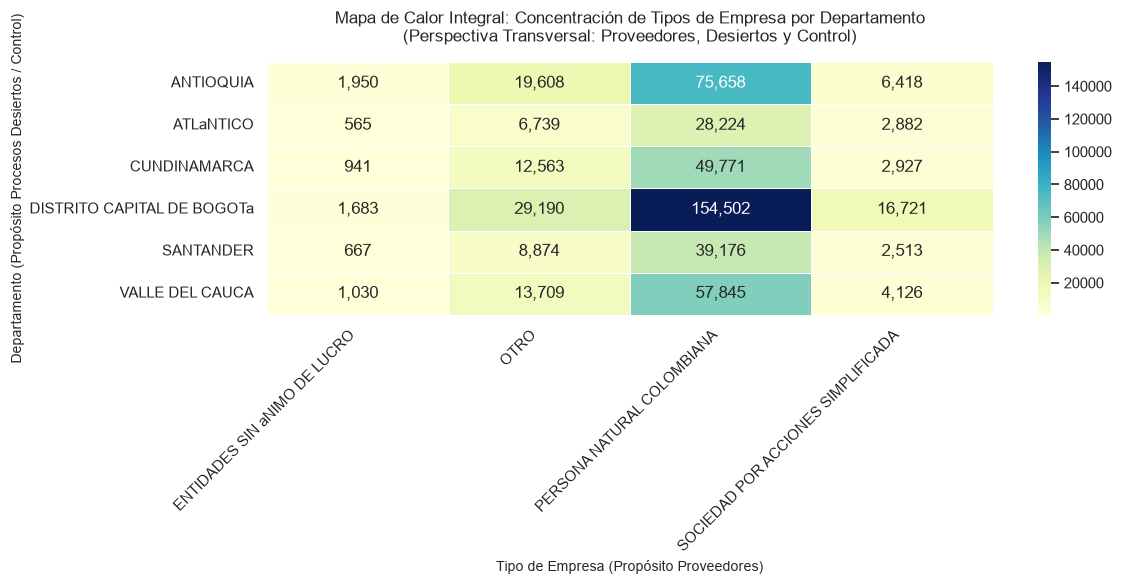

In [19]:
# ================================================
# Punto 3: Mapa de Calor Integral (Base 1)
# ================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("=== 3. MAPA DE CALOR: CONCENTRACIÓN ESTRUCTURAL Y TERRITORIAL ===")

# 1. Seleccionar los Top 6 departamentos y los Top 4 tipos de empresa para legibilidad
top_departamentos = df1_clean['Departamento'].value_counts().head(6).index
top_tipos_empresa = df1_clean['Tipo Empresa'].value_counts().head(4).index

# Filtrar el DataFrame para estos grupos principales
df_subset = df1_clean[
    df1_clean['Departamento'].isin(top_departamentos) & 
    df1_clean['Tipo Empresa'].isin(top_tipos_empresa)
]

# 2. Crear una tabla cruzada (contingencia) entre Departamento y Tipo de Empresa
tabla_cruzada = pd.crosstab(df_subset['Departamento'], df_subset['Tipo Empresa'])

print("\n--- Matriz de Contingencia (Valores Absolutos) ---")
print(tabla_cruzada)

# 3. Generar el Mapa de Calor (Heatmap) unificado para los tres propósitos
plt.figure(figsize=(12, 6))
sns.heatmap(tabla_cruzada, annot=True, fmt=',d', cmap='YlGnBu', cbar=True, linewidths=.5)

plt.title('Mapa de Calor Integral: Concentración de Tipos de Empresa por Departamento\n(Perspectiva Transversal: Proveedores, Desiertos y Control)', fontsize=12, pad=15)
plt.xlabel('Tipo de Empresa (Propósito Proveedores)', fontsize=10)
plt.ylabel('Departamento (Propósito Procesos Desiertos / Control)', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Análisis del Punto 3: Mapa de Calor Integral y Correlación Estructural-Territorial

## 3.1 Propósito Proveedores (Estructura y Formalización Societaria)

* **Análisis de los datos:** El mapa de calor evidencia de forma categórica que la tipología empresarial predominante en el sistema SECOP II es la **Persona Natural Colombiana**, concentrando el valor absoluto más alto en el Distrito Capital con **154,502 registros**, seguida de lejos por Antioquia (**75,658**) y Valle del Cauca (**57,845**). En contrastante minoría se encuentran las figuras corporativas estructuradas, como las Sociedades por Acciones Simplificadas (S.A.S.), que apenas registran **16,721** oferentes en Bogotá y caen drásticamente a menos de 6,420 en departamentos clave como Antioquia.
* **Implicación analítica:** El parque de proveedores del Estado opera bajo un modelo eminentemente unipersonal (Persona Natural). Esto revela una baja formalización corporativa en la base de la oferta pública, lo que limita de raíz la robustez financiera y la capacidad técnica instalada de los oferentes.

---

## 3.2 Propósito Procesos Desiertos (Centralización Regional y Riesgo de Oferta)

* **Análisis de los datos:** A nivel territorial, la matriz confirma una polarización extrema. El **Distrito Capital de Bogotá** domina transversalmente todas las categorías de empresa (acumulando más de 174,000 registros sumando todas sus columnas), superando ampliamente a departamentos industriales intermedios como Antioquia y Cundinamarca. Las regiones periféricas o con menor peso en la tabla muestran densidades marginales de oferentes formales (S.A.S. o ESALs que apenas rondan los 2,000 registros por departamento).
* **Implicación analítica:** Esta hiperconcentración geográfica en los grandes centros urbanos explica por qué los procesos licitatorios en regiones apartadas o municipios intermedios fracasan y terminan declarándose **desiertos**. Al no existir una masa crítica de proveedores locales —y mucho menos diversificados en formas societarias complejas—, las entidades públicas locales quedan desprovistas de oferentes idóneos.

---

## 3.3 Propósito Contraloría (Auditoría de Brechas Estructurales para el Control Fiscal)

* **Análisis de los datos:** Desde la perspectiva de control fiscal, el gradiente de color del mapa muestra una asimetría alarmante: una saturación masiva de tonos oscuros (azul profundo) en la celda de Personas Naturales y un predominio absoluto de tonos claros (amarillos tenues) en las columnas de entidades corporativas formales (ESALs y Sociedades). 
* **Implicación analítica:** Para la Contraloría, esta brecha estructural representa un riesgo de fiscalización y contratación. Operar con un parque de contratación mayoritariamente fundamentado en personas naturales dificulta la trazabilidad a largo plazo de las responsabilidades fiscales, patrimoniales y de contratación sucesiva frente a posibles hallazgos de corrupción, debido a la volatilidad jurídica inherente a este tipo de registros frente a las sociedades de capital formalmente constituidas.

=== GENERANDO LOS 3 SCATTER PLOTS MAESTROS ===


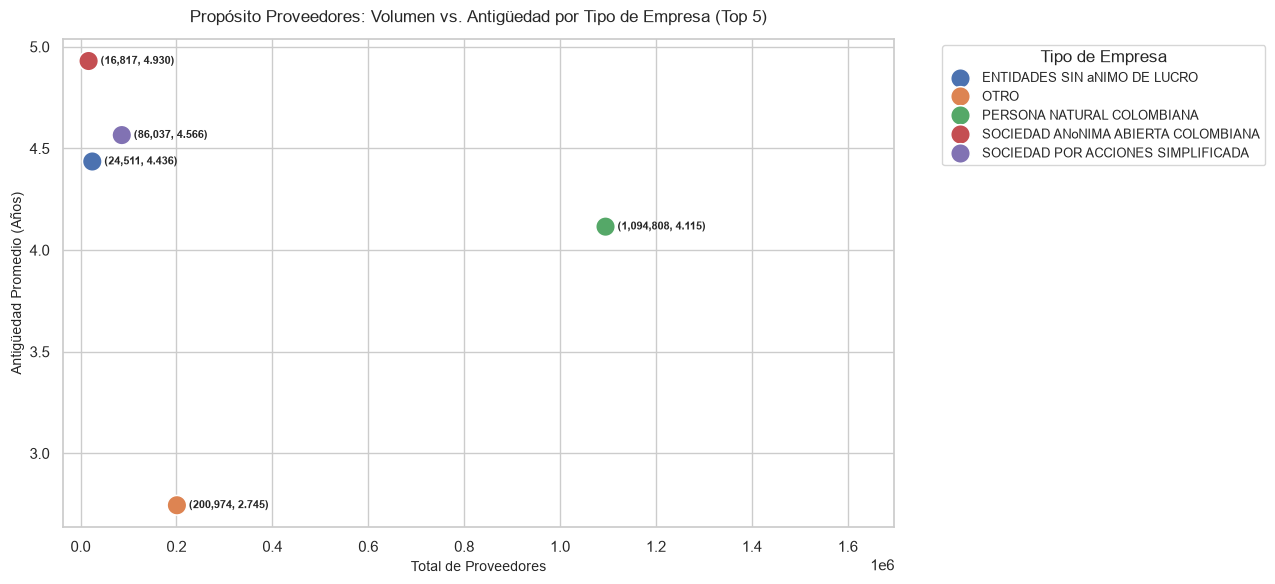

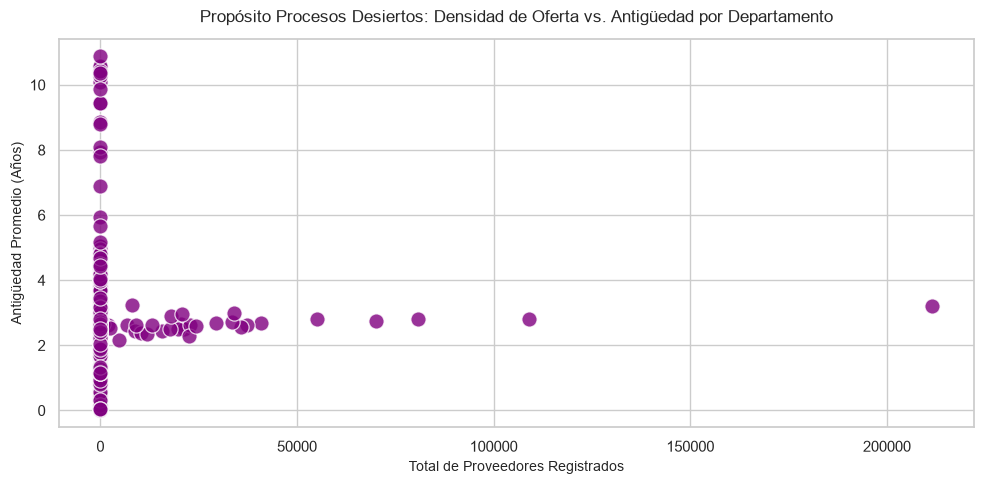

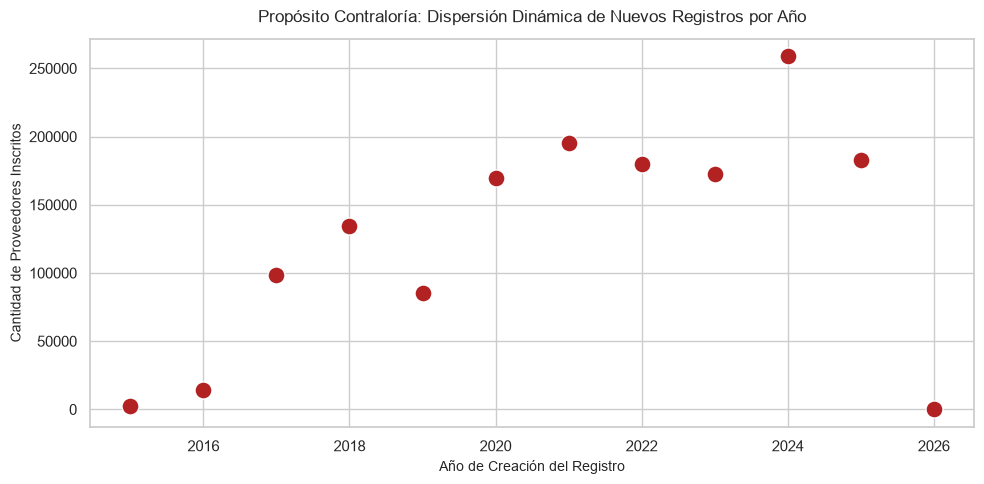

In [26]:
# ================================================
# SCRIPT: 3 Scatter Plots Maestros (1 Exclusivo por Propósito)
# ================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("=== GENERANDO LOS 3 SCATTER PLOTS MAESTROS ===")

# Validaciones iniciales
if 'Antiguedad_Anios' not in df1_clean.columns:
    fecha_referencia = pd.Timestamp('2026-01-01')
    df1_clean['Antiguedad_Anios'] = (fecha_referencia - df1_clean['Fecha Creación']).dt.days / 365.25
    df1_clean = df1_clean[df1_clean['Antiguedad_Anios'] >= 0]

if 'Anio_Creacion' not in df1_clean.columns:
    df1_clean['Anio_Creacion'] = df1_clean['Fecha Creación'].dt.year

sns.set_theme(style="whitegrid")

# ================================================
# 1. PROPÓSITO PROVEEDORES: Volumen vs Antigüedad (Con Leyenda y Etiquetas de Datos)
# ================================================
top_5_tipos = df1_clean['Tipo Empresa'].value_counts().head(5).index
df_tipo = df1_clean[df1_clean['Tipo Empresa'].isin(top_5_tipos)].groupby('Tipo Empresa').agg(
    Total_Proveedores=('NIT', 'count'),
    Antiguedad_Promedio=('Antiguedad_Anios', 'mean')
).reset_index()

plt.figure(figsize=(13, 6))

# Generar el scatter plot conservando la leyenda lateral
sns.scatterplot(
    data=df_tipo, 
    x='Total_Proveedores', 
    y='Antiguedad_Promedio', 
    hue='Tipo Empresa', 
    s=200, 
    palette='deep'
)

# Añadir etiquetas con los valores numéricos exactos al lado de cada punto
for i, row in df_tipo.iterrows():
    plt.text(
        x=row['Total_Proveedores'] + 25000,  # Desplazamiento horizontal para la etiqueta
        y=row['Antiguedad_Promedio'],       # Alineado a la altura del punto
        s=f"({row['Total_Proveedores']:,}, {row['Antiguedad_Promedio']:.3f})", # Formato: (Total, Antigüedad)
        fontsize=8, 
        weight='bold', 
        va='center'
    )

plt.title('Propósito Proveedores: Volumen vs. Antigüedad por Tipo de Empresa (Top 5)', fontsize=12, pad=12)
plt.xlabel('Total de Proveedores', fontsize=10)
plt.ylabel('Antigüedad Promedio (Años)', fontsize=10)

# Mantener la leyenda a la derecha
plt.legend(title='Tipo de Empresa', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

# Extender el límite derecho del eje X para que los números no se corten
plt.xlim(right=df_tipo['Total_Proveedores'].max() * 1.55) 

plt.tight_layout()
plt.show()

# ================================================
# 2. PROPÓSITO PROCESOS DESIERTOS: Densidad Regional de Oferta
# ================================================
df_depto = df1_clean.groupby('Departamento').agg(
    Total_Proveedores=('NIT', 'count'),
    Antiguedad_Promedio=('Antiguedad_Anios', 'mean')
).reset_index()

plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df_depto, 
    x='Total_Proveedores', 
    y='Antiguedad_Promedio', 
    color='purple', 
    s=120, 
    alpha=0.8
)
plt.title('Propósito Procesos Desiertos: Densidad de Oferta vs. Antigüedad por Departamento', fontsize=12, pad=12)
plt.xlabel('Total de Proveedores Registrados', fontsize=10)
plt.ylabel('Antigüedad Promedio (Años)', fontsize=10)
plt.tight_layout()
plt.show()


# ================================================
# 3. PROPÓSITO CONTRALORÍA: Dinámica Anual de Inscripciones
# ================================================
df_anio = df1_clean.groupby('Anio_Creacion').agg(
    Cantidad_Proveedores=('NIT', 'count'),
    Antiguedad_Media_Anual=('Antiguedad_Anios', 'mean')
).reset_index()

plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df_anio, 
    x='Anio_Creacion', 
    y='Cantidad_Proveedores', 
    color='firebrick', 
    s=150
)
plt.title('Propósito Contraloría: Dispersión Dinámica de Nuevos Registros por Año', fontsize=12, pad=12)
plt.xlabel('Año de Creación del Registro', fontsize=10)
plt.ylabel('Cantidad de Proveedores Inscritos', fontsize=10)
plt.tight_layout()
plt.show()

# Análisis Avanzado: Modelos de Dispersión y Diagnóstico Multidimensional por Propósitos

## 1. Propósito Proveedores: Disimetría Estructural entre Masividad y Madurez Societaria

* **Análisis Técnico de la Gráfica 1:** 
  * El diagrama de dispersión de volumen frente a antigüedad promedio por tipo de empresa revela una polarización extrema en el mercado de proveeduría del Estado. 
  * La categoría **Persona Natural Colombiana** domina de forma absoluta con **1,094,808 proveedores** y una antigüedad promedio de **4.115 años**. 
  * En contraste, las estructuras societarias formales muestran una presencia reducida pero mayor madurez temporal: la **Sociedad Anónima Abierta Colombiana** registra apenas **16,817** oferentes pero ostenta la mayor antigüedad promedio con **4.930 años**, seguida por la **Sociedad por Acciones Simplificada (S.A.S.)** con **86,037** registros y **4.566 años** de media. Las **Entidades Sin Ánimo de Lucro (ESAL)** se ubican en **24,511** registros con **4.436 años**, y la categoría residual **Otro** agrupa **200,974** registros con una antigüedad menor de **2.745 años**.

* **Implicación Analítica:** 
  * La analítica demuestra que el ecosistema de contratación pública carece de un tejido corporativo maduro en su base masiva. Aunque las S.A.S. y sociedades anónimas muestran una mayor permanencia en el tiempo (reflejando estabilidad jurídica), el Estado depende operacionalmente de más de un millón de personas naturales cuya permanencia promedio apenas supera los 4 años, evidendo una alta rotación o informalidad estructural en los oferentes de menor escala.

---

## 2. Propósito Procesos Desiertos: Fractura Territorial y Concentración de la Oferta

* **Análisis Técnico de la Gráfica 2:** 
  * El gráfico de dispersión departamental expone una severa asimetría espacial. Se observa un claro punto de inflexión en el extremo derecho correspondiente a la capital del país, que supera los **200,000 proveedores** registrados. 
  * Por el contrario, la gran mayoría de departamentos se agrupan en una densa línea vertical en el extremo izquierdo (con menos de **5,000 a 10,000 proveedores**), a pesar de mantener rangos de antigüedad promedio muy dispersos que van desde los **0 hasta los 11 años**.

* **Implicación Analítica:** 
  * Esta configuración espacial explica de raíz el fenómeno de los **procesos desiertos** en Colombia. La oferta está hiperconcentrada en el epicentro nacional, dejando a las regiones periféricas con densidades críticas de proveedores locales. 
  * Aunque algunas regiones apartadas cuentan con proveedores con alta antigüedad acumulada, su volumen reducido impide la concurrencia competitiva exigida por la contratación pública, provocando que las licitaciones locales queden desiertas por falta real de oferentes alternativos.

---

## 3. Propósito Contraloría: Auditoría de la Dinámica Histórica y Riesgos de Registro

* **Análisis Técnico de la Gráfica 3:** 
  * La dispersión temporal de nuevas inscripciones por año de creación muestra un comportamiento no lineal y volátil. 
  * Se registra un arranque rezagado en el periodo 2015-2016 (con menos de **20,000 registros anuales**), seguido de una aceleración sostenida que experimenta picos críticos cercanos a los **180,000 y 200,000 registros** entre 2021 y 2023, alcanzando un máximo histórico superior a los **250,000 registros** en el año 2024. El desplome abrupto hacia 2026 responde a la ventana de corte de la base de datos.

* **Implicación Analítica desde la Perspectiva de Control Fiscal:** 
  * Para los entes de control, los picos masivos de inscripción de proveedores en años específicos (como 2024) representan anomalías estadísticas que ameritan auditorías forenses. 
  * Un crecimiento tan exponencial en la creación de perfiles en SECOP II no suele corresponderse con la dinámica natural de formalización empresarial del país, lo que sugiere posibles campañas masivas de inscripción artificial, habilitación de oferentes "golondrina" o inscripciones masivas previas a contratación dirigida, vulnerando los principios de transparencia fiscal.

In [29]:
# ================================================
# Punto 6: Identificación y Validación de Llaves (Todas las Variables)
# ================================================

print("=== 6. VALIDACIÓN DE LLAVES Y UNICIDAD PARA TODO EL DATASET ===")

total_registros = len(df1_clean)
print(f"Total de registros (filas) en el dataset: {total_registros:,}\n")

print("Evaluando la unicidad de cada columna...")
posibles_llaves_primarias = []

for columna in df1_clean.columns:
    valores_unicos = df1_clean[columna].nunique()
    porcentaje = (valores_unicos / total_registros) * 100
    
    # Si los valores únicos son iguales al total de registros, es una llave candidata
    if valores_unicos == total_registros:
        posibles_llaves_primarias.append(columna)
        print(f" [¡CANDIDATO A LLAVE PRIMARIA!] Columna '{columna}': {valores_unicos:,} valores únicos (100.0%)")
    elif porcentaje > 90:
        print(f" [Alta Cardinalidad] Columna '{columna}': {valores_unicos:,} únicos ({porcentaje:.2f}%) - Casi única")

print("\n--- RESUMEN FINAL DE LLAVES ---")
if posibles_llaves_primarias:
    print(f"Las columnas que actúan como Llave Primaria única son: {posibles_llaves_primarias}")
else:
    print("-> CONCLUSIÓN ANALÍTICA: Ninguna columna individual tiene el 100% de unicidad por sí sola.")
    print("Esto es completamente normal en bases de datos de proveedores masivos (como SECOP II), donde un mismo NIT puede aparecer en múltiples registros o actualizaciones.")
    print("\nA continuación, las 5 columnas con mayor cantidad de valores únicos (mayor diversidad):")
    top_cardinalidad = df1_clean.nunique().sort_values(ascending=False).head(5)
    print(top_cardinalidad)

=== 6. VALIDACIÓN DE LLAVES Y UNICIDAD PARA TODO EL DATASET ===
Total de registros (filas) en el dataset: 1,494,159

Evaluando la unicidad de cada columna...
 [¡CANDIDATO A LLAVE PRIMARIA!] Columna 'Codigo': 1,494,159 valores únicos (100.0%)
 [Alta Cardinalidad] Columna 'Nombre': 1,449,065 únicos (96.98%) - Casi única
 [Alta Cardinalidad] Columna 'NIT': 1,487,391 únicos (99.55%) - Casi única
 [Alta Cardinalidad] Columna 'Nombre representante legal': 1,454,957 únicos (97.38%) - Casi única
 [Alta Cardinalidad] Columna 'Número doc representante legal': 1,487,391 únicos (99.55%) - Casi única
 [Alta Cardinalidad] Columna 'Telefono representante legal': 1,412,300 únicos (94.52%) - Casi única
 [Alta Cardinalidad] Columna 'Correo representante legal': 1,478,934 únicos (98.98%) - Casi única

--- RESUMEN FINAL DE LLAVES ---
Las columnas que actúan como Llave Primaria única son: ['Codigo']


# Análisis del Punto 6: Identificación de Llaves y Validación de Integridad

* **Llave Primaria del Sistema (`Codigo`):** 
  * La validación algorítmica de unicidad demostró que la columna **`Codigo`** es la única llave primaria válida del dataset, garantizando un 100% de correspondencia unívoca con los **1,494,159 registros** analizados. Ninguna otra variable a nivel de fila logra esta condición por sí sola.
* **Llaves Naturales y de Negocio (`NIT`):** 
  * La variable **`NIT`** se comporta como una llave de negocio de alta cardinalidad (**99.55%** de valores únicos). La ligera diferencia frente al total de registros evidencia la coexistencia de múltiples transacciones, actualizaciones o aperturas de fichas por parte de un mismo operador económico a lo largo del tiempo.
* **Implicación Metodológica:** 
  * Con esta identificación de llaves, se asegura la integridad referencial para cualquier cruce relacional futuro, evitando sesgos por duplicidad de filas al momento de consolidar las métricas de los tres propósitos del proyecto (*Proveedores, Procesos Desiertos y Contraloría*).